### This is an adaptation of the 2003 Bengo et al paper: A Neural Probabilistic Language Model - Char-Level Language model

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [3]:
with open('names.txt', 'r') as f:
    names = f.readlines()

# reemove trailing line break 
names = [name[:-1] for name in names]

In [4]:
# get the vocab
vocab = sorted(list(set(''.join(names))))
vocab = vocab + ['.']
vocab

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 '.']

In [5]:
# create a mapping of char to num and num to char
# make sure . is mapped to 0

# encoder
char2num = {c: i+1 for i, c in enumerate(vocab)}
char2num['.'] = 0
# decoder
num2char = {i: c for c, i in char2num.items()}

In [ ]:
# # buidl the training set
# block_size = 3    # context length    
# X, y = [], []

# for name in names:
#     # initialize context as all padding (all dots = index 0)
#     context = [0] * block_size
#     for char in name+'.':
#         print(f"context: {context}, char: {char}")
#         ix = char2num[char] # get the index of the char
#         X.append(context)
#         y.append(ix)
#         print(f"{(''.join(num2char[i]) for i in context)} -----> {num2char[ix]}")
#         context = context[1:] + [ix]

In [ ]:
# # build the training set
# block_size = 3    # context length    
# X, y = [], []

# for name in names[:3]:
#     context = [0] * block_size
#     for char in name + '.':
#         ix = char2num[char]
#         X.append(context)
#         y.append(ix)
#         print(f"{''.join(num2char[i] for i in context)} -----> {num2char[ix]}")
#         context = context[1:] + [ix]


... -----> e
..e -----> m
.em -----> m
emm -----> a
mma -----> .
... -----> o
..o -----> l
.ol -----> i
oli -----> v
liv -----> i
ivi -----> a
via -----> .
... -----> a
..a -----> v
.av -----> a
ava -----> .


In [ ]:
# from collections import deque

# block_size = 3
# X, y = [], []
# for name in names:
#     context = deque([0] * block_size, maxlen=3)
#     for char in name + '.':
#         ix = char2num[char]
#         X.append(list(context))
#         y.append(ix)
#         context.append(ix)
        

In [7]:
# build the training set
from collections import deque # use double ended queue for sliding window

block_size = 3    # context length    
X, y = [], []

for name in names[:5]:
    context = deque([0] * block_size, maxlen=3)
    print(name)
    for char in name + '.':
        ix = char2num[char]
        X.append(list(context))
        y.append(ix)
        print(f"{''.join(num2char[i] for i in context)} -----> {num2char[ix]}")
        context.append(ix)
        
X = torch.tensor(X)
y = torch.tensor(y)

emma
... -----> e
..e -----> m
.em -----> m
emm -----> a
mma -----> .
olivia
... -----> o
..o -----> l
.ol -----> i
oli -----> v
liv -----> i
ivi -----> a
via -----> .
ava
... -----> a
..a -----> v
.av -----> a
ava -----> .
isabella
... -----> i
..i -----> s
.is -----> a
isa -----> b
sab -----> e
abe -----> l
bel -----> l
ell -----> a
lla -----> .
sophia
... -----> s
..s -----> o
.so -----> p
sop -----> h
oph -----> i
phi -----> a
hia -----> .


In [8]:
X.shape, y.shape

(torch.Size([32, 3]), torch.Size([32]))

Now we have the X and y data ready in tensor form

## Building the Neural Network
- input layer has 3 chars, each char is a 2-dim feature vector (emb)
- one hidden layer with 100 neurons - hyperparam - design choice
- output layer with 27 possible chars, then apply softmax to output highest prob

In [ ]:
# C is a tensor that represents the embeddings of each char in the vocab
# C.shape = (27, 2)
# init randomly and will be trained - C is part of the weights
C = torch.randn((27, 2))

# embed each char in a 2-dim vector space

In [18]:
C[5]

tensor([-0.3291,  1.0491])

In [19]:
# same result as cell above
# in matmul we dotprod the first row of the onehot encoded tensor
# which is a vector of len 27, with the first and second column of C,
# so all the zeros in the row one hot vector end up masking out 
# all other chars embeddings and pluck out only the embedding 
# for the desired index in this case idx 5
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-0.3291,  1.0491])

In [ ]:
# here we do not want to one-hot encode, but wanna embed chars in a 2-dim space
# xenc = F.one_hot(X, num_classes=27) X
# xenc.shape X

In [ ]:
# how do we simultaneously embed all training examples in X
# torch indexing
# 1- indexing with a int
print(C[5])
print()
print()
# 2- indexing with a list
print(C[[1,2,3,4,4,4]])
print()
print()
# 3- indexing with a 1-D torch tensor
print(C[torch.tensor([1,2,3,4,4,4])])
print()
print()
# 4- indexing with a 2-D torch tensor
print(C[torch.tensor([[1,2,3],[4,4,4]])])

tensor([-0.3291,  1.0491])


tensor([[-0.6471, -1.1243],
        [ 0.3248,  1.1611],
        [ 0.7243,  1.2300],
        [-0.1084, -1.4548],
        [-0.1084, -1.4548],
        [-0.1084, -1.4548]])


tensor([[-0.6471, -1.1243],
        [ 0.3248,  1.1611],
        [ 0.7243,  1.2300],
        [-0.1084, -1.4548],
        [-0.1084, -1.4548],
        [-0.1084, -1.4548]])


tensor([[[-0.6471, -1.1243],
         [ 0.3248,  1.1611],
         [ 0.7243,  1.2300]],

        [[-0.1084, -1.4548],
         [-0.1084, -1.4548],
         [-0.1084, -1.4548]]])


In [35]:
C[torch.tensor([[1,2,3],[4,4,4]])].shape

torch.Size([2, 3, 2])

In [36]:
C

tensor([[ 0.6659,  0.0078],
        [-0.6471, -1.1243],
        [ 0.3248,  1.1611],
        [ 0.7243,  1.2300],
        [-0.1084, -1.4548],
        [-0.3291,  1.0491],
        [ 0.2709, -1.1001],
        [ 1.1099, -0.5952],
        [-0.0174,  0.8303],
        [ 0.4487, -1.2645],
        [ 1.5555, -0.2238],
        [ 0.7439,  0.2306],
        [-0.1328,  1.3756],
        [ 0.2812,  0.0556],
        [-0.5603, -1.0134],
        [ 0.1941, -0.2277],
        [ 1.3273, -0.7128],
        [ 0.0466,  0.9875],
        [ 1.5036,  1.3032],
        [-1.2548, -0.9944],
        [ 0.2467, -1.8613],
        [-0.0373,  1.4203],
        [-0.1736,  2.0764],
        [ 0.2642, -0.3861],
        [-0.5599, -0.7034],
        [ 1.7311,  1.4452],
        [-1.0973,  0.2596]])

In [ ]:
# each int index in X retrieves the corresponding elemnt in C, 
# examine X and C[X] to gain a deeper intuition
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [40]:
C[X]

tensor([[[ 0.6659,  0.0078],
         [ 0.6659,  0.0078],
         [ 0.6659,  0.0078]],

        [[ 0.6659,  0.0078],
         [ 0.6659,  0.0078],
         [-0.3291,  1.0491]],

        [[ 0.6659,  0.0078],
         [-0.3291,  1.0491],
         [ 0.2812,  0.0556]],

        [[-0.3291,  1.0491],
         [ 0.2812,  0.0556],
         [ 0.2812,  0.0556]],

        [[ 0.2812,  0.0556],
         [ 0.2812,  0.0556],
         [-0.6471, -1.1243]],

        [[ 0.6659,  0.0078],
         [ 0.6659,  0.0078],
         [ 0.6659,  0.0078]],

        [[ 0.6659,  0.0078],
         [ 0.6659,  0.0078],
         [ 0.1941, -0.2277]],

        [[ 0.6659,  0.0078],
         [ 0.1941, -0.2277],
         [-0.1328,  1.3756]],

        [[ 0.1941, -0.2277],
         [-0.1328,  1.3756],
         [ 0.4487, -1.2645]],

        [[-0.1328,  1.3756],
         [ 0.4487, -1.2645],
         [-0.1736,  2.0764]],

        [[ 0.4487, -1.2645],
         [-0.1736,  2.0764],
         [ 0.4487, -1.2645]],

        [[-0.1736,  2

In [ ]:
C[X].shape
# 32 training examples, each is 3 integers, each int has a 2-dim embedding

torch.Size([32, 3, 2])

In [44]:
X[4, 2]

tensor(1)

In [ ]:
C[X][4, 2] # gives us the 2-dim embedding for the int 1

tensor([-0.6471, -1.1243])

In [49]:
C[1]

tensor([-0.6471, -1.1243])

## Create Embedding Tensor and init W, b

In [74]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

### first hidden layer

In [75]:
W1 = torch.randn((100, 6)) # (out_dim, in_dim)
b1 = torch.randn((100,  )) # (out_dim,       )

In [76]:
# forward pass
# z
#      (32, 6)  @  (6, 100) + (100, ) 
z1 = emb.view(-1,6) @ W1.T + b1
z1.shape

torch.Size([32, 100])

In [77]:
h1 = torch.tanh(z)
h1.shape

torch.Size([32, 100])

In [78]:
# broadcasting
# 32, 100 -> h
# 1,  100 -> b

In [79]:
emb.view(-1, 6).shape

torch.Size([32, 6])

In [80]:
emb.shape

torch.Size([32, 3, 2])

### second hidden layer

In [81]:
W2 = torch.randn((27, 100))
b2 = torch.randn((27,))
#.   (32,100)    (100, 27)  (27,)
z2 = h1      @    W2.T     + b2
z2.shape

torch.Size([32, 27])

In [82]:
counts = z2.exp()
probs = counts / counts.sum(dim=1, keepdim=True)

In [ ]:
probs.sum(1) # all rows sum up to 1

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [85]:
probs.shape

torch.Size([32, 27])

In [86]:
y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [87]:
probs[torch.arange(len(y)), y]

tensor([8.6162e-13, 6.2765e-05, 1.4499e-08, 1.2195e-07, 1.6856e-12, 4.9318e-12,
        2.7502e-13, 2.0571e-08, 2.8576e-06, 1.2087e-12, 1.0788e-10, 5.5261e-10,
        1.4656e-15, 2.3938e-05, 3.1466e-05, 9.6014e-15, 1.3527e-11, 5.5137e-11,
        4.4073e-04, 1.4152e-11, 5.3845e-09, 5.2792e-06, 1.0451e-10, 1.1115e-10,
        2.7806e-16, 4.7342e-13, 3.6559e-01, 5.8082e-11, 5.6552e-08, 2.6976e-13,
        1.4851e-11, 1.9475e-07])

In [89]:
# loss function is the negative log liklielooh
loss = -probs[torch.arange(len(y)), y].log().mean()
loss.item()

21.135616302490234

### Reorganizing the code

In [5]:
# build the training set
from collections import deque # use double ended queue for sliding window

block_size = 3    # context length    
X, y = [], []

for name in names:
    context = deque([0] * block_size, maxlen=3)
    # print(name)
    for char in name + '.':
        ix = char2num[char]
        X.append(list(context))
        y.append(ix)
        # print(f"{''.join(num2char[i] for i in context)} -----> {num2char[ix]}")
        context.append(ix)
        
X = torch.tensor(X)
y = torch.tensor(y)

In [6]:
X.shape

torch.Size([228145, 3])

In [7]:
# init the parameters
C = torch.randn((27, 2),    requires_grad=True)
W1 = torch.randn((100, 6),  requires_grad=True)
b1 = torch.randn((100, ),   requires_grad=True)
W2 = torch.randn((27, 100), requires_grad=True)
b2 = torch.randn((27, ),    requires_grad=True)
params = [C, W1, b1, W2, b2]
sum([p.numel() for p in params])

3481

In [ ]:
# # forward pass
# emb = C[X]
# h = torch.tanh(emb.view(-1,6) @ W1.T + b1)
# # output layer
# logits = h @ W2.T + b2
# loss = F.cross_entropy(logits, y) # instead of doing couonts and probs
# # F.cross_entropy is 1) more efficient in forward pass,
# # 2) more efficient in backward pass,
# # 3) and numerically stable
# loss

tensor(15.9754, grad_fn=<NllLossBackward0>)

In [ ]:
# # backwards pass

# # zero grads before backprop
# for w in params:
#     w.grad = None

# # backprop and populate grads in the computation graph    
# loss.backward()

# # update weights
# for w in params:
#     w.data += -0.1 * w.grad

In [16]:
# this implementation uses GD, which does the forward pass, backward pass, and update on the entire training data
# that's why it's a bit slow

# lr optimization
lre = torch.linspace(-3, 0, 500)
lrs = 10**lre

lri   = []
stepi = []
lossi = []

for i in range(500):
    ######### forward pass #########
    emb = C[X]
    h = torch.tanh(emb.view(-1,6) @ W1.T + b1)
    logits = h @ W2.T + b2
    loss = F.cross_entropy(logits, y)
    # print(loss.item())
    
    ######### backwards pass #########
    # zero grads before backprop
    for w in params:
        w.grad = None

    # backprop and populate grads in the computation graph    
    loss.backward()

    ######### update weights #########
    lr = lrs[i]
    for w in params:
        w.data += -lr * w.grad
    
    lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.item())
       

print(loss.item())  

5.462146282196045


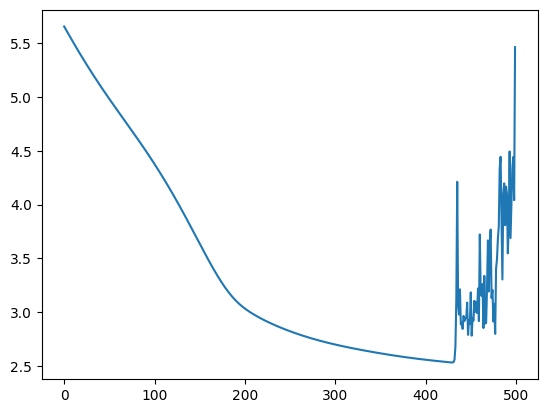

In [17]:
plt.plot(stepi, lossi)
plt.show()

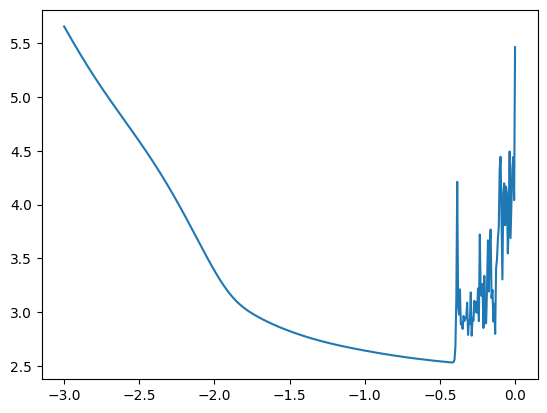

In [18]:
plt.plot(lri, lossi)
plt.show()

In [ ]:
# -------------------------- USING MINI BATCH GD   -------------------------- #

In [19]:
# build the training set
from collections import deque # use double ended queue for sliding window

block_size = 3    # context length    
X, y = [], []

for name in names:
    context = deque([0] * block_size, maxlen=3)
    # print(name)
    for char in name + '.':
        ix = char2num[char]
        X.append(list(context))
        y.append(ix)
        # print(f"{''.join(num2char[i] for i in context)} -----> {num2char[ix]}")
        context.append(ix)
        
X = torch.tensor(X)
y = torch.tensor(y)

In [20]:
# init the parameters
C = torch.randn((27, 2),   requires_grad=True)
W1 = torch.randn((100, 6), requires_grad=True)
b1 = torch.randn((100, ),  requires_grad=True)
W2 = torch.randn((27, 100),requires_grad=True)
b2 = torch.randn((27, ),   requires_grad=True)
params = [C, W1, b1, W2, b2]
sum([p.numel() for p in params])

3481

In [ ]:
# this implementation uses mini batch GD

for _ in range(1000):
    # batch index - each batch is 64 examples
    bix = torch.randint(0, len(X), (64,))
    ######### forward pass #########
    emb = C[X[bix]]
    h = torch.tanh(emb.view(-1,6) @ W1.T + b1)
    logits = h @ W2.T + b2
    loss = F.cross_entropy(logits, y[bix])
    # print(loss.item())
    
    ######### backwards pass #########
    # zero grads before backprop
    for w in params:
        w.grad = None

    # backprop and populate grads in the computation graph    
    loss.backward()

    ######### update weights #########
    # initital lr = 0.1
    # then we do a lr decay to 0.01
    for w in params:
        w.data += -0.0001 * w.grad
        
# the loss for a mini batch
print(round(loss.item(), 4))  

2.2695


In [47]:
# eval loss on entire data
emb = C[X]
h = torch.tanh(emb.view(-1,6) @ W1.T + b1)
logits = h @ W2.T + b2
loss = F.cross_entropy(logits, y)
print(round(loss.item(), 4))

2.4442


## Splitting the data and retraining 

In [66]:
from collections import deque # use double ended queue for sliding window

def build_dataset(names):
    # build the training set
    block_size = 3    # context length    
    X, y = [], []
    for name in names:
        context = deque([0] * block_size, maxlen=3)
        # print(name)
        for char in name + '.':
            ix = char2num[char]
            X.append(list(context))
            y.append(ix)
            # print(f"{''.join(num2char[i] for i in context)} -----> {num2char[ix]}")
            context.append(ix)
            
    X = torch.tensor(X)
    y = torch.tensor(y)
    
    return X, y

In [67]:
import random
random.shuffle(names)

train_split = int(0.8 * len(names))
valid_split = int(0.9 * len(names))

In [68]:
X_train, y_train = build_dataset(names[:train_split])
X_valid, y_valid = build_dataset(names[train_split:valid_split])
X_test,  y_test  = build_dataset(names[valid_split:])

In [69]:
# init the parameters

embedding_dim = 2
first_hidden_layer_units = 100

C = torch.randn((27, embedding_dim),                           requires_grad=True)
W1 = torch.randn((first_hidden_layer_units, embedding_dim*3),  requires_grad=True)
b1 = torch.randn((first_hidden_layer_units, ),                 requires_grad=True)
W2 = torch.randn((27, first_hidden_layer_units),               requires_grad=True)
b2 = torch.randn((27, ),                                       requires_grad=True)
params = [C, W1, b1, W2, b2]
sum([p.numel() for p in params])

3481

In [76]:
# this implementation uses mini batch GD
# train on X_train, y_train

# optimize learning rate
# lre = torch.linspace(-3, 0, 1000)
# lrs = 10**lre

# lri = []
# lossi = []

for i in range(10000):
    # batch index - each batch is 64 examples
    bix = torch.randint(0, len(X_train), (64,))
    ######### forward pass #########
    emb = C[X_train[bix]]
    h = torch.tanh(emb.view(-1,6) @ W1.T + b1)
    logits = h @ W2.T + b2
    loss = F.cross_entropy(logits, y_train[bix])
    # print(loss.item())
    
    ######### backwards pass #########
    # zero grads before backprop
    for w in params:
        w.grad = None

    # backprop and populate grads in the computation graph    
    loss.backward()

    ######### update weights #########
    # lr = lrs[i]
    lr = 0.1
    for w in params:
        w.data += -lr * w.grad
    
    ######## stats ########
    # lri.append(lre[i])
    # lossi.append(loss.item())
    
# the loss for a mini batch
print(round(loss.item(), 4))  

2.2156


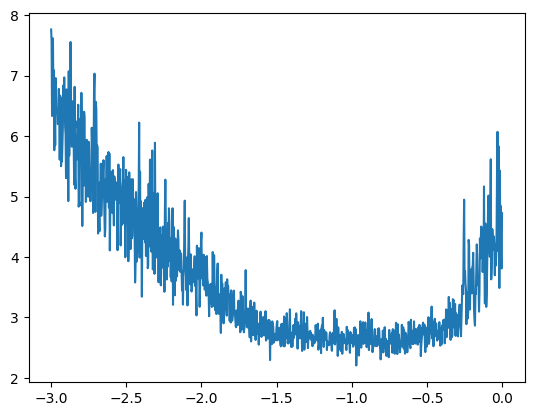

In [72]:
plt.plot(lre, lossi)

In [ ]:
# training loss over entire training set

emb = C[X_train]
h = torch.tanh(emb.view(-1,6) @ W1.T + b1)
logits = h @ W2.T + b2
loss = F.cross_entropy(logits, y_train)
print(loss.item())

2.396726131439209


In [ ]:
# val loss over entire validation set
emb = C[X_valid]
h = torch.tanh(emb.view(-1,6) @ W1.T + b1)
logits = h @ W2.T + b2
loss = F.cross_entropy(logits, y_valid)
print(loss.item())

2.3127429485321045


#### the train and valid loss are almost equal, which means that the model is not overfitting the training data yet, which could indicate that we might gain performance improvement by increasing the size of the network.

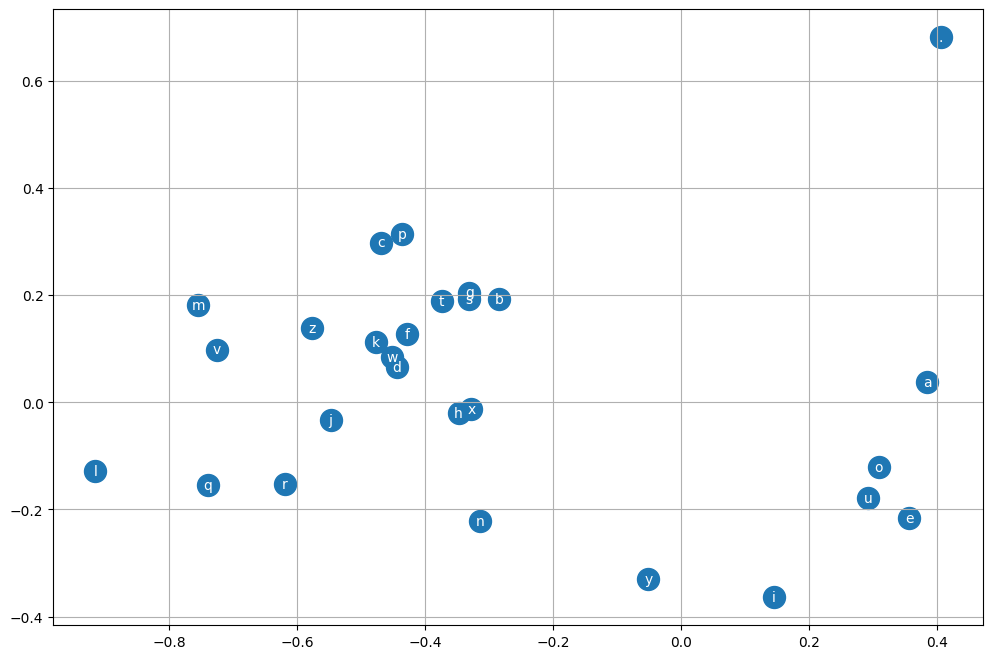

In [79]:
plt.figure(figsize=(12,8))
plt.scatter(C[:, 0].detach(), C[:, 1].detach(), s=250)
for i in range(27):
    plt.text(C[i, 0].item(), C[i, 1].item(), num2char[i], ha='center', va='center', color='white')
plt.grid()
plt.show()

## Scaling Up the Network

In [116]:
# init the parameters

embedding_dim = 10
first_hidden_layer_units = 200

C = torch.randn((27, embedding_dim),   requires_grad=True)
W1 = torch.randn((first_hidden_layer_units, embedding_dim*3), requires_grad=True)
b1 = torch.randn((first_hidden_layer_units, ),  requires_grad=True)
W2 = torch.randn((27, first_hidden_layer_units),requires_grad=True)
b2 = torch.randn((27, ),   requires_grad=True)
params = [C, W1, b1, W2, b2]
sum([p.numel() for p in params])

11897

In [117]:
stepi = []
lossi = []

In [122]:
for i in range(10000):
    # batch index - each batch is 64 examples
    bix = torch.randint(0, len(X_train), (64,))
    ######### forward pass #########
    emb = C[X_train[bix]]
    h = torch.tanh(emb.view(-1,embedding_dim*3) @ W1.T + b1)
    logits = h @ W2.T + b2
    loss = F.cross_entropy(logits, y_train[bix])
    
    ######### backwards pass #########
    # zero grads before backprop
    for w in params:
        w.grad = None

    # backprop and populate grads in the computation graph    
    loss.backward()
    
    # update params
    lr = 0.1
    for w in params:
        w.data += -lr * w.grad
        
    stepi.append(i)
    lossi.append(loss.item())
    
# the loss for a mini batch
print(round(loss.item(), 4))  

2.0323


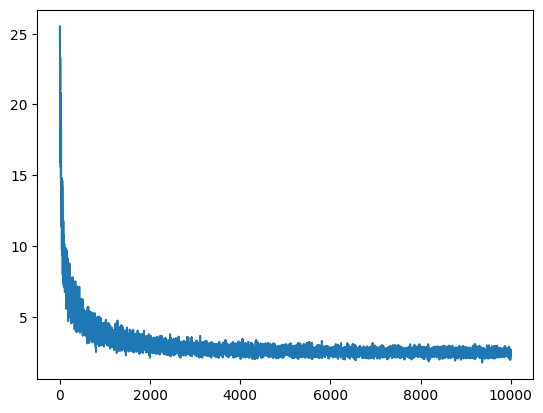

In [119]:
plt.plot(stepi, lossi)

In [123]:
# loss for entire training set
# shape of C (27, 10)
emb = C[X_train]    # (182392, 3, 10)
# shape of h (182392, 200) =   (182392, 30) @ (30, 200)
h = torch.tanh(emb.view(X_train.shape[0], 30) @ W1.T + b1)
# shape logits (182392, 200) @ (200, 27) = (182392, 27)
logits = h @ W2.T + b2
loss = F.cross_entropy(logits, y_train)
loss.item()

2.2811737060546875

In [124]:
# loss for entire val set
# shape of C (27, 10)
emb = C[X_valid]    # (182392, 3, 10)
# shape of h (182392, 200) =   (182392, 30) @ (30, 200)
h = torch.tanh(emb.view(X_valid.shape[0], 30) @ W1.T + b1)
# shape logits (182392, 200) @ (200, 27) = (182392, 27)
logits = h @ W2.T + b2
loss = F.cross_entropy(logits, y_valid)
loss.item()

2.296581268310547

# Further Experimentation
### knobs to tweak
- dim of embedding, currently 10
- number of inputs to the NN, currently 3
- number of neurons in hidden layer, currently 200
- batch size
- details of the optimization process
    - num iterations/epochs
    - lr, lr decay, or how lr changes over time (simple if-else)

Try to beat 2.17 on valid loss

In [ ]:
# init the parameters

embedding_dim = 50
first_hidden_layer_units = 400

C = torch.randn((27, embedding_dim),   requires_grad=True) # (27, 20)
W1 = torch.randn((first_hidden_layer_units, embedding_dim*3), requires_grad=True)
b1 = torch.randn((first_hidden_layer_units, ),  requires_grad=True)
W2 = torch.randn((27, first_hidden_layer_units),requires_grad=True)
b2 = torch.randn((27, ),   requires_grad=True)
params = [C, W1, b1, W2, b2]
sum([p.numel() for p in params])

72577

In [223]:
for i in range(100000):
    # batch index - each batch is 64 examples
    bix = torch.randint(0, len(X_train), (128,))
    ######### forward pass #########
    emb = C[X_train[bix]]
    h = torch.tanh(emb.view(-1,embedding_dim*3) @ W1.T + b1)
    logits = h @ W2.T + b2
    loss = F.cross_entropy(logits, y_train[bix])
    
    ######### backwards pass #########
    # zero grads before backprop
    for w in params:
        w.grad = None

    # backprop and populate grads in the computation graph    
    loss.backward()
    
    # update params
    # lr = 0.1
    # lr = 0.000000000000001
    lr = 0.1 if i < 50000 else 0.001
    for w in params:
        w.data += -lr * w.grad
        
    # stepi.append(i)
    # lossi.append(loss.item())
    
# the loss for a mini batch
print(round(loss.item(), 4))  

2.0557


In [224]:
# loss for entire training set
# shape of C (27, 10)
emb = C[X_train]    # (182392, 3, 10)
# shape of h (182392, 200) =   (182392, 30) @ (30, 200)
h = torch.tanh(emb.view(X_train.shape[0], 3*embedding_dim) @ W1.T + b1)
# shape logits (182392, 200) @ (200, 27) = (182392, 27)
logits = h @ W2.T + b2
loss = F.cross_entropy(logits, y_train)
loss.item()

2.026124954223633

In [225]:
# loss for entire val set
# shape of C (27, 10)
emb = C[X_valid]    # (182392, 3, 10)
# shape of h (182392, 200) =   (182392, 30) @ (30, 200)
h = torch.tanh(emb.view(X_valid.shape[0], 3*embedding_dim) @ W1.T + b1)
# shape logits (182392, 200) @ (200, 27) = (182392, 27)
logits = h @ W2.T + b2
loss = F.cross_entropy(logits, y_valid)
loss.item()

2.2606101036071777

# Sampling from the model

In [232]:
context = [0] * 3
torch.tensor([context]).shape #.unsqueeze(0).shape

torch.Size([1, 3])

In [235]:
# loop to sample chars and generate names
g = torch.Generator().manual_seed(2147483647)
out = []
block_size = 3
for i in range(20):
    # idx = 0 # start token 
    chars = [] # to store the chars of the name
    context = [0] * 3
    while True:
        # forward pass
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1.T + b1)
        logits = h @ W2.T + b2        
        probs = F.softmax(logits, dim=1)
        
        idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()    
        context = context[1:] + [idx]
        
        if idx == 0: # end token
            break
        chars.append(num2char[idx])
    out.append(''.join(chars))

In [236]:
out

['celie',
 'moulsey',
 'roczeny',
 'kell',
 'ima',
 'tainella',
 'kaman',
 'a',
 'samiyah',
 'javarii',
 'tai',
 'molie',
 'cayu',
 'keyton',
 'jenne',
 'kamside',
 'enkavion',
 'ryklen',
 'hunte',
 'bron']

# Initializing the Weights like a Pro

- Our network has been initialized poorly - as it starts of with a very high loss around 17.
- We can manullay calcualte the loss for the first iteration (random guesses) to get an idea of where our loss should start
- it is almost always the case that when building NNs, we can manually calc the initial loss, depending on the loss fn and the problem set up
- in our case, we have 27 chars. At initialization we have no reason to believe that the network should assign a higher prob to any char. So, we expect a uniform distribution of equally likely next tokens.
- to calc this, the prob of any char coming next is 1/27
- since we are using the NLL Loss, we can easily get the loss as follows:

## 1- First Problem
### Initializing the W, b:
to inint the weights of a NN, we wannna make sure the Ws are close to 0, i.e. we scale them down, and set the b to zero at init. Thhis will get us very clos to a uniform distribution, and the correct loss that we expect at init.

In [ ]:
-torch.tensor(1/27.0).log()
# so 3.29 is the initial loss we would expect 

tensor(3.2958)

In [ ]:
logits = torch.zeros((4,)) # ([0,0,0,0])
probs = F.softmax(logits, dim=0)
loss = -probs[1].log()
probs, loss # 1.36 is the loss we expect at init

(tensor([0.2500, 0.2500, 0.2500, 0.2500]), tensor(1.3863))

In [ ]:
logits = torch.tensor([0.0, 10.0, 0.0, 0.0])
probs = F.softmax(logits, dim=0)
loss = -probs[1].log() # pron[1] is the prob of the label
probs, loss # if the logit is high for idx 1 that means that the 
# pred matches the correct label \, so the loss is 0

(tensor([4.5394e-05, 9.9986e-01, 4.5394e-05, 4.5394e-05]), tensor(0.0001))

In [ ]:
logits = torch.tensor([0.0, 0.0, 0.0, 10.0])
probs = F.softmax(logits, dim=0)
loss = -probs[1].log() # pron[1] is the prob of the label
probs, loss # high loss, incorrect pred

(tensor([4.5394e-05, 4.5394e-05, 4.5394e-05, 9.9986e-01]), tensor(10.0001))

In [ ]:
logits = torch.randn(4) # logits are normally dist, mean=0, std=1, low loss
probs = F.softmax(logits, dim=0)
loss = -probs[1].log() # pron[1] is the prob of the label
probs, loss

(tensor([0.4082, 0.0884, 0.3366, 0.1669]), tensor(2.4263))

In [ ]:
logits = torch.randn(4) * 10 # large weights, very high loss
probs = F.softmax(logits, dim=0)
loss = -probs[1].log() # pron[1] is the prob of the label
probs, loss

(tensor([2.7995e-10, 2.6960e-15, 7.7668e-01, 2.2332e-01]), tensor(33.5470))

In [6]:
from collections import deque # use double ended queue for sliding window

def build_dataset(names):
    # build the training set
    block_size = 3    # context length    
    X, y = [], []
    for name in names:
        context = deque([0] * block_size, maxlen=3)
        # print(name)
        for char in name + '.':
            ix = char2num[char]
            X.append(list(context))
            y.append(ix)
            # print(f"{''.join(num2char[i] for i in context)} -----> {num2char[ix]}")
            context.append(ix)
            
    X = torch.tensor(X)
    y = torch.tensor(y)
    
    return X, y

In [7]:
import random
random.shuffle(names)

train_split = int(0.8 * len(names))
valid_split = int(0.9 * len(names))

In [8]:
X_train, y_train = build_dataset(names[:train_split])
X_valid, y_valid = build_dataset(names[train_split:valid_split])
X_test,  y_test  = build_dataset(names[valid_split:])

In [132]:
# init the parameters
block_size = 3
embedding_dim = 10
first_hidden_layer_units = 200

C  = torch.randn((27, embedding_dim),                           requires_grad=True)
W1 = torch.randn((first_hidden_layer_units, embedding_dim*3),   requires_grad=True)
b1 = torch.randn((first_hidden_layer_units, ),                  requires_grad=True)
W2 = (torch.randn((27, first_hidden_layer_units)) * 0.01).requires_grad_(True)
b2 = torch.zeros((27, ),                                        requires_grad=True)
params = [C, W1, b1, W2, b2]
sum([p.numel() for p in params])

11897

In [107]:
# this implementation uses mini batch GD
# train on X_train, y_train

# optimize learning rate
# lre = torch.linspace(-3, 0, 1000)
# lrs = 10**lre

# lri = []
stepi = []
lossi = []

for i in range(10000):
    # batch index - each batch is 64 examples
    bix = torch.randint(0, len(X_train), (64,))
    ######### forward pass #########
    emb = C[X_train[bix]]
    z = emb.view(-1,block_size*embedding_dim) @ W1.T + b1
    h = torch.tanh(z)
    ##################################################
    # we need to make logits close to zero to get a uniform dist
    logits = h @ W2.T + b2
    # b2=0 at init, and W2 close to 0
    ##################################################
    loss = F.cross_entropy(logits, y_train[bix])
    # print(loss.item())
    
    ######### backwards pass #########
    # zero grads before backprop
    for w in params:
        w.grad = None

    # backprop and populate grads in the computation graph    
    loss.backward()

    ######### update weights #########
    # lr = lrs[i]
    lr = 0.1
    for w in params:
        w.data += -lr * w.grad
    
    ######## stats ########
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.item())
    
# the loss for a mini batch
print(round(loss.item(), 4))  

2.1178


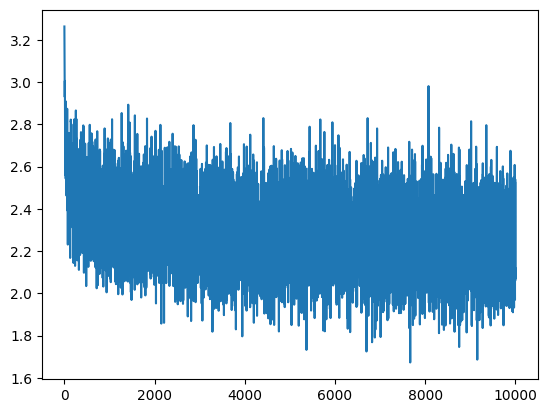

In [108]:
plt.plot(stepi, lossi)

# the loss does not look like a hockey stick anymore, which is exactly what we wnat

In [110]:
def loss_for_split(split):
    x, y = {'train': (X_train, y_train),
     'val': (X_valid, y_valid),
     'test': (X_test, y_test)}[split]
    
    emb = C[x]
    h = torch.tanh(emb.view(-1,block_size*embedding_dim) @ W1.T + b1)
    logits = h @ W2.T + b2
    loss = F.cross_entropy(logits, y)
    print(loss.item())
    
loss_for_split('train')
loss_for_split('val')
loss_for_split('test')

2.2504756450653076
2.264585256576538
2.26401948928833


## 2- Second Problem in param initialization
the output of the pre-activations (Zs) of the hidden layer has many extreme values, and thus the activations (h) are saturated at the 1 and -1 ends. Thus causes the grad during backprop to be zeroed out according to the backward implementation of the tanh function in the Tensor object class (see Value object from micrograd).

the solution: is to scale down the weight matrix (W1, mu=0, std=1) so that the z (z = x@W+b) has mu=0 (which comes naturally) and std=1/ we scale W1 by a facter gain/sqrt(fan_in) to shrink the std of z

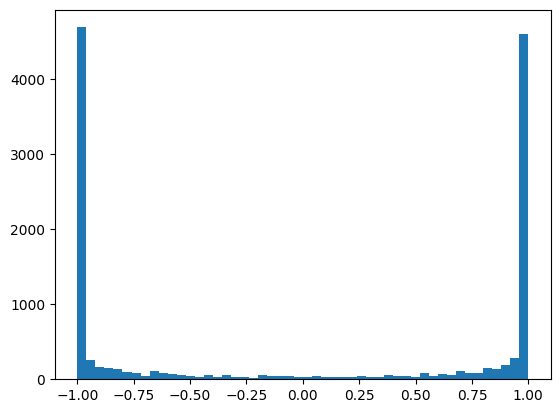

In [112]:
plt.hist(h.view(-1).tolist(), 50);

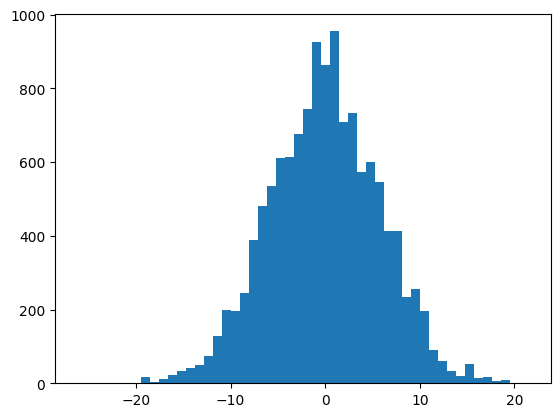

In [113]:
plt.hist(z.view(-1).tolist(), 50);

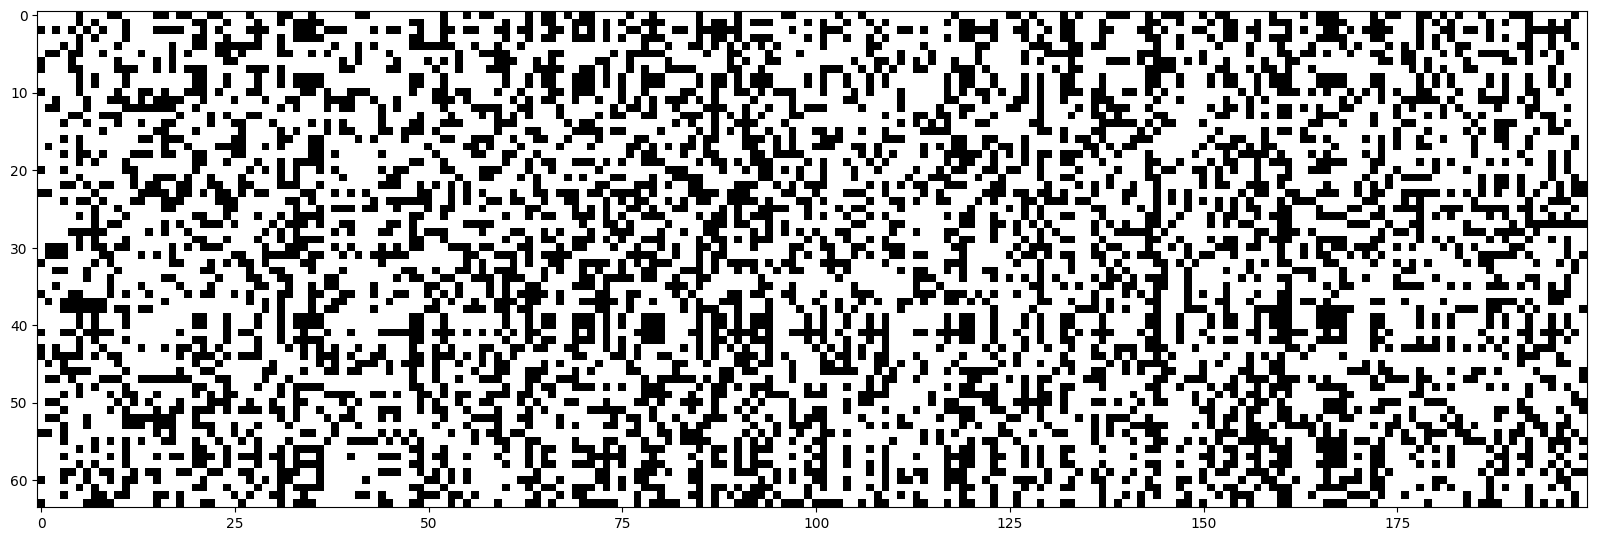

In [ ]:
plt.figure(figsize=(20,8))
plt.imshow((h.abs() > 0.99), cmap='grey', interpolation='nearest')
plt.show()
# white means true => means that we are in the flat part of the tanh => dead grad

# black means false => means that we are in the curved part of the tanh => healthy grad

# in this graph we wanna look for a white column which 
# means we have a neuron that has not been activation by any of 
# the training examples as they flow through the layer. this said neuron cannot learn and is dead
# if the W and b are init a certain way and our training examples lead our Zs (pre-act) to land in the flat part of the tanh.
# for all X train, then we have a dead neuron and this is a big problemo, amigo!


In [ ]:
(h.abs() > 0.99).unique(return_counts=True)

# observation: number of activations that are very close to 1 or -1 is 2/3 of the total num of act, 
# for all these hs, the gradient is gonna be dead because of the flat tail of tanh

# looking back at the backward_ implementation in mircograd:
'''
    # o is a resuklt of a tanh so when we call o._backward()
    def tanh(self):
        # out = tanh(self)
        # defining the local derivative of tanh with respect to its input self
        # dout/dself = 1 - tanh^2 = 1 - out.data^2
        x = self.data
        t = (np.exp(2 * x) - 1) / (np.exp(2 * x) + 1)
        out = Value(t, (self,), "tanh")

        # a closure is a record that stores a function together with an environment.
        def _backward():  # local d  * global d
        ####self.grad += (1 - t**2) * out.grad ################# <<<<<<<<
            # out.grad is chained (backpropped) to z.grad thru the local derv of tanh (1-tanh^2)
            # when t is 1 or -1 -> (1 - t**2) = 0, and so the grad for that node is zero
            no learning happening - vanishing gradient
        out._backward = _backward
        return out

'''

(tensor([False,  True]), tensor([4632, 8168]))

the same problem of vanishing grads also happens in other nonlinearities like sigmoid and ReLU.

### how to detect dead neurons in the NN?

after training, depending on the non-linearity used, we forward pass the entire training set to the model and we start scrutininzing the Zs (pre-acts) and Hs (acts), like how we did above with the plot then we look for white cols in the plot

### fixing/mitigating the vanishing grad problem

the problem start with Z, the pre-act, so we need to understand how we arrived at Z

```python
emb = C[X]
z = emb.view(-1,block_size*embedding_dim) @ W1.T + b1
h = torch.tanh(z)
logits = h @ W2.T + b2
```

W, b, C (through emb) --> Z --> Z is normally dist but its std is different. the bell curve grows wide (less peaky) i.e. we have high std

In [ ]:
t = torch.randn(10000) * 0.5
t.mean(), t.std() 

(tensor(0.0005), tensor(0.4940))

In [125]:
W1.mean(), W1.std()

(tensor(-0.0145, grad_fn=<MeanBackward0>),
 tensor(0.9931, grad_fn=<StdBackward0>))

In [ ]:
z.mean(), z.std() # note the high std

(tensor(-0.0372, grad_fn=<MeanBackward0>),
 tensor(5.8261, grad_fn=<StdBackward0>))

In [12]:
# init the parameters
block_size = 3
embedding_dim = 10
first_hidden_layer_units = 200
w_std = 5 / (3 * np.sqrt(embedding_dim*block_size))


C  = torch.randn((27, embedding_dim),                           requires_grad=True)
W1 = (torch.randn((first_hidden_layer_units, embedding_dim*3)) * w_std).requires_grad_(True)
b1 = torch.randn((first_hidden_layer_units, ),                  requires_grad=True)
W2 = (torch.randn((27, first_hidden_layer_units)) * 0.01).requires_grad_(True)
b2 = torch.zeros((27, ),                                        requires_grad=True)
params = [C, W1, b1, W2, b2]
sum([p.numel() for p in params])

11897

In [ ]:
# this implementation uses mini batch GD
# train on X_train, y_train

# optimize learning rate
# lre = torch.linspace(-3, 0, 1000)
# lrs = 10**lre

# lri = []
stepi = []
lossi = []

for i in range(10000):
    # batch index - each batch is 64 examples
    bix = torch.randint(0, len(X_train), (64,))
    ######### forward pass #########
    emb = C[X_train[bix]]
    z = emb.view(-1,block_size*embedding_dim) @ W1.T + b1
    h = torch.tanh(z)
    ##################################################
    # we need to make logits close to zero to get a uniform dist
    logits = h @ W2.T + b2
    # b2=0 at init, and W2 close to 0
    ##################################################
    loss = F.cross_entropy(logits, y_train[bix])
    # print(loss.item())
    
    ######### backwards pass #########
    # zero grads before backprop
    for w in params:
        w.grad = None

    # backprop and populate grads in the computation graph    
    loss.backward()

    ######### update weights #########
    # lr = lrs[i]
    lr = 0.1
    for w in params:
        w.data += -lr * w.grad
    
    ######## stats ########
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.item())
    
# the loss for a mini batch
print(round(loss.item(), 4))  

1.9927


In [ ]:
# z before scaling down W1
z.mean(), z.std()

(tensor(-0.0152, grad_fn=<MeanBackward0>),
 tensor(5.4637, grad_fn=<StdBackward0>))

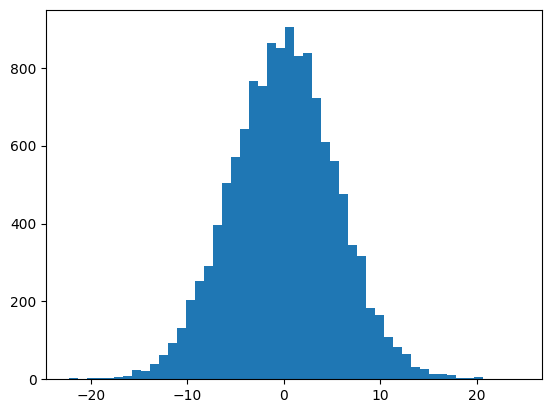

In [ ]:
plt.hist(z.view(-1).tolist(), 50)
plt.show()

In [14]:
# z after scaling down W1
z.mean(), z.std()

(tensor(0.0131, grad_fn=<MeanBackward0>),
 tensor(2.1112, grad_fn=<StdBackward0>))

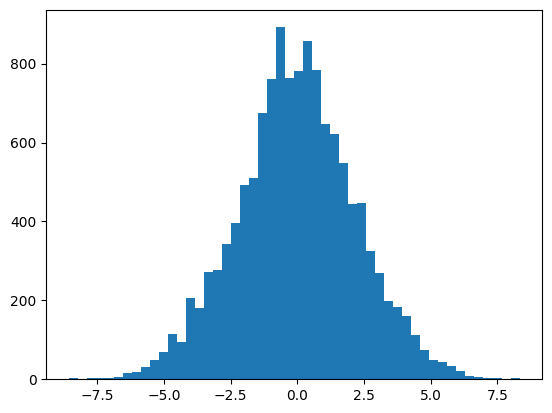

In [176]:
plt.hist(z.view(-1).tolist(), 50)
plt.show()

In [11]:
# std = gain / sqrt(fan_in) this is the std of the init distribution 
# for W1, where fan_in is the number of inputs to the layer 
# (embedding_dim*block_size) and gain is 5/3 for tanh activation function
# w_std = 5/3 / np.sqrt(embedding_dim*block_size)

In [16]:
5/3 / np.sqrt(embedding_dim*block_size)

np.float64(0.3042903097250923)

In [15]:
5 / (3 * np.sqrt(embedding_dim*block_size))

np.float64(0.3042903097250923)

In [ ]:
### --------------------------- BREAK ------------------ 

In [ ]:
### --------------------------- BREAK ------------------ 

In [ ]:
### --------------------------- BREAK ------------------ 

## Batch Normalization
Batch norm `nn.BatchNorm1d()` basically normalizes the output of activations (h) to be mean=0 and std=1 so that gradients flow more smoothly through the activation node and we mitigate the vanishing gradient problem.

See histogram of h above - it shows how it is saturated at the 2 extremes, which kills the gradient signal in the backward pass. See tanh backward implementation: 1 - t**2 evals to 0 for most values of h

batch norm fixes this distributionissue by taking the z-score of the preactivations (z) ==> z_hat = (z_i - z_mean) / z_std,

then weight * z_hat + bias ==> where weight is gain or gamma, and bias removes the need for a bias in the previous layer.

note: when we use batch norm we do not use biases in the layer before it as they are redundnat and do not learn, because they get subtracted out during the calc of z_hat. so we set bias=False in the Linear or Conv layer before the batch norm layer.